# Federated Learning Sweep — Results Analysis

Parse every `results/{exp_id}/history.json` into a tidy DataFrame and explore:
- Effect of **data distribution** and **number of clients** on global val loss
- The three **gradient-divergence plateaus** (optimizer × FedProx)
- **FedProx regularization** effect per optimizer
- **FedAvg vs FedAdam** comparison
- **Dirichlet α** heterogeneity sweep
- FL vs **centralized baseline**

## 1. Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# ── adjust this if you used --results-dir ──────────────────────────────────
RESULTS_DIR = Path("results")
FIGS_DIR    = Path("figs_analysis")
FIGS_DIR.mkdir(exist_ok=True)

## 2. Load results

In [2]:
def load_all_results(results_dir: Path) -> list:
    records, missing = [], []
    for exp_dir in sorted(results_dir.iterdir()):
        if not exp_dir.is_dir():
            continue
        p = exp_dir / "history.json"
        if p.exists():
            with open(p) as f:
                data = json.load(f)
            data["exp_id"] = exp_dir.name
            records.append(data)
        else:
            missing.append(exp_dir.name)
    print(f"✓ Loaded  : {len(records)} experiments")
    if missing:
        print(f"✗ Missing : {len(missing)} — {missing[:8]}{'...' if len(missing)>8 else ''}")
    return records

records  = load_all_results(RESULTS_DIR)
by_id    = {r["exp_id"]: r for r in records}   # quick lookup by exp_id

✓ Loaded  : 120 experiments


## 3. Build summary DataFrame

In [3]:
def _dist_label(cfg: dict) -> str:
    d = cfg.get("data_distribution", "?")
    return f"dirichlet α={cfg.get('dirichlet_alpha')}" if d == "dirichlet" else d

def _div_group(row) -> str:
    """Map (optimizer, regularization) → one of the 3 observed divergence plateaus."""
    opt  = row["optimizer"]
    reg  = row["regularization"]
    if opt in ("adamw", "adam") and reg == "none":
        return "adam(w) — no FedProx"
    elif opt == "sgd":
        return f"sgd — {reg}"
    else:   # adam(w) + fedprox
        return "adam(w) — FedProx"

def build_df(records: list) -> pd.DataFrame:
    rows = []
    for r in records:
        cfg = r.get("config", {})
        h   = r.get("history", {})
        bh  = r.get("baseline_history") or {}

        gvl = h.get("global_val_loss", [])
        gd  = h.get("grad_divergence", [])
        rt  = h.get("round_times", [])
        ltr = h.get("local_train_losses", [])
        lvl = h.get("local_val_losses", [])

        ltr_mean = [np.mean(x) for x in ltr] if ltr else []
        lvl_mean = [np.mean(x) for x in lvl] if lvl else []

        bl_val = (bh.get("val_loss") or [np.nan])[-1]

        row = {
            "exp_id":           r["exp_id"],
            "num_clients":      cfg.get("num_clients"),
            "distribution":     cfg.get("data_distribution"),
            "dist_label":       _dist_label(cfg),
            "dirichlet_alpha":  cfg.get("dirichlet_alpha"),
            "aggregator":       cfg.get("aggregator"),
            "regularization":   cfg.get("client_regularization") or "none",
            "optimizer":        cfg.get("optimizer"),
            "num_rounds":       cfg.get("num_rounds"),

            "final_global_val":  gvl[-1]  if gvl else np.nan,
            "best_global_val":   min(gvl) if gvl else np.nan,
            "final_local_train": ltr_mean[-1] if ltr_mean else np.nan,
            "final_local_val":   lvl_mean[-1] if lvl_mean else np.nan,

            "mean_grad_div":     np.mean(gd) if gd else np.nan,
            "final_grad_div":    gd[-1]  if gd else np.nan,

            "mean_round_time":   np.mean(rt) if rt else np.nan,
            "total_fl_time_min": r.get("total_fl_time", np.nan) / 60,

            "baseline_final_val": bl_val,
            "fl_minus_baseline":  (gvl[-1] - bl_val) if gvl else np.nan,
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    df["div_group"]  = df.apply(_div_group, axis=1)
    df["clients_str"] = df["num_clients"].astype(str) + " clients"
    return df

df = build_df(records)
print(f"DataFrame: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Distributions : {sorted(df['distribution'].unique())}")
print(f"Aggregators   : {sorted(df['aggregator'].unique())}")
print(f"Optimizers    : {sorted(df['optimizer'].unique())}")
print(f"Regularization: {sorted(df['regularization'].unique())}")
print(f"Num clients   : {sorted(df['num_clients'].unique())}")

DataFrame: 120 rows × 21 cols
Distributions : ['dirichlet', 'multi_language', 'single_language']
Aggregators   : ['fedadam', 'fedavg']
Optimizers    : ['adam', 'adamw', 'sgd']
Regularization: ['fedprox', 'none']
Num clients   : [np.int64(4), np.int64(32)]


### 3a. Quick overview

In [4]:
# Top 10 experiments by final global val loss (lower = better)
cols_show = ["exp_id","num_clients","distribution","aggregator","regularization",
             "optimizer","final_global_val","baseline_final_val","fl_minus_baseline"]
df.sort_values("final_global_val")[cols_show].head(10).style.background_gradient(
    subset=["final_global_val"], cmap="RdYlGn_r"
)

,exp_id,num_clients,distribution,aggregator,regularization,optimizer,final_global_val,baseline_final_val,fl_minus_baseline
94,c4_dirichlet2.0_fedavg_none_adamw,4,dirichlet,fedavg,none,adamw,4.441119,4.180112,0.261007
93,c4_dirichlet2.0_fedavg_none_adam,4,dirichlet,fedavg,none,adam,4.446316,4.188895,0.257421
106,c4_multi_language_fedavg_none_adamw,4,multi_language,fedavg,none,adamw,4.446611,4.181414,0.265196
105,c4_multi_language_fedavg_none_adam,4,multi_language,fedavg,none,adam,4.446938,4.189163,0.257775
82,c4_dirichlet0.5_fedavg_none_adamw,4,dirichlet,fedavg,none,adamw,4.460881,4.183453,0.277429
81,c4_dirichlet0.5_fedavg_none_adam,4,dirichlet,fedavg,none,adam,4.469333,4.190019,0.279314
70,c4_dirichlet0.1_fedavg_none_adamw,4,dirichlet,fedavg,none,adamw,4.606828,4.184026,0.422801
69,c4_dirichlet0.1_fedavg_none_adam,4,dirichlet,fedavg,none,adam,4.611700,4.189923,0.421778
61,c4_dirichlet0.1_fedadam_fedprox_adamw,4,dirichlet,fedadam,fedprox,adamw,4.852621,4.181029,0.671592
73,c4_dirichlet0.5_fedadam_fedprox_adamw,4,dirichlet,fedadam,fedprox,adamw,4.855243,4.179744,0.675499


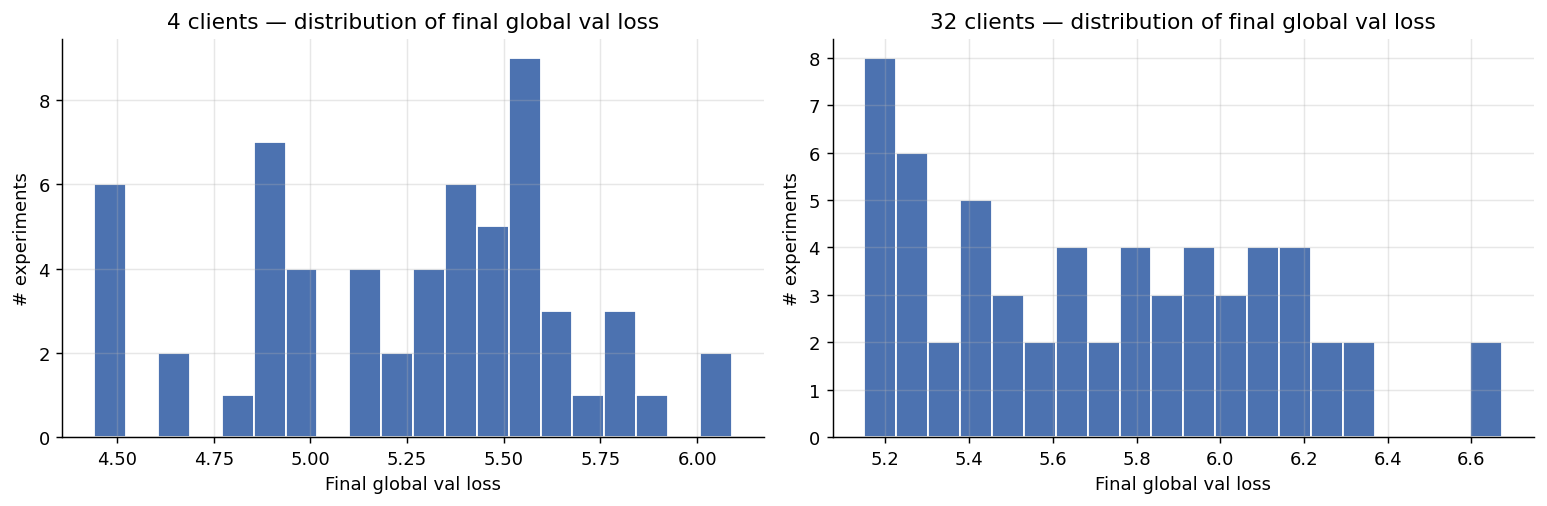

In [5]:
# Distribution of final val losses
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, nc in zip(axes, [4, 32]):
    sub = df[df["num_clients"] == nc]
    ax.hist(sub["final_global_val"].dropna(), bins=20, edgecolor="white", color="#4C72B0")
    ax.set_title(f"{nc} clients — distribution of final global val loss")
    ax.set_xlabel("Final global val loss"); ax.set_ylabel("# experiments")
plt.tight_layout()
plt.savefig(FIGS_DIR / "00_val_loss_histogram.png", bbox_inches="tight")
plt.show()

## 4. Effect of data distribution and number of clients

Mean ± std of final global val loss across all (aggregator, regularization, optimizer) combinations.

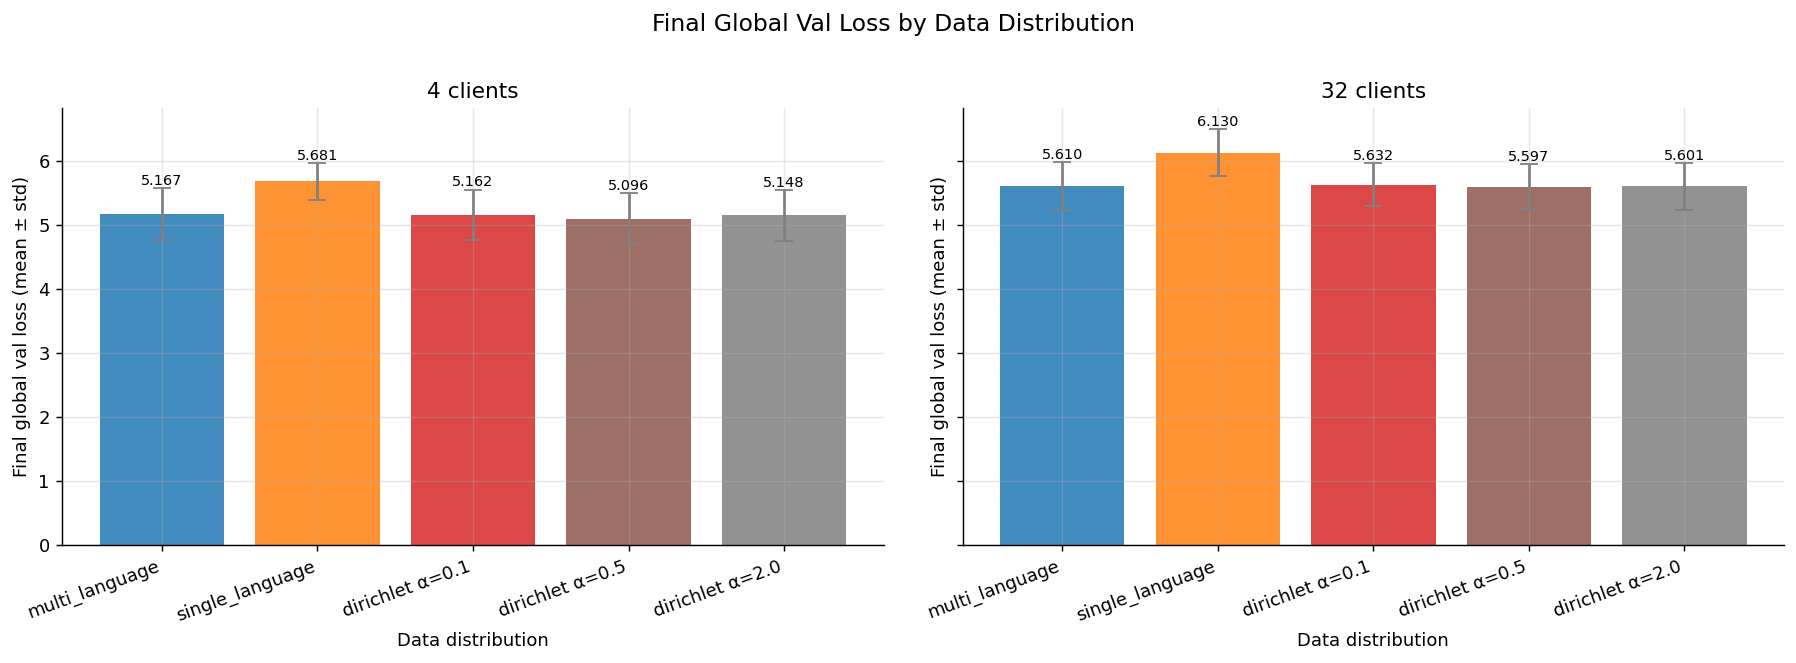

In [6]:
DIST_ORDER = ["multi_language", "single_language",
              "dirichlet α=0.1", "dirichlet α=0.5", "dirichlet α=2.0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, nc in zip(axes, [4, 32]):
    sub = df[df["num_clients"] == nc].copy()
    grp = sub.groupby("dist_label")["final_global_val"].agg(["mean","std","count"])
    # sort by our preferred order
    order = [d for d in DIST_ORDER if d in grp.index]
    grp = grp.reindex(order)

    colors = plt.cm.tab10(np.linspace(0, 0.7, len(grp)))
    bars = ax.bar(range(len(grp)), grp["mean"], yerr=grp["std"],
                  capsize=5, color=colors, alpha=0.85, ecolor="gray")
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp.index, rotation=20, ha="right")
    ax.set_title(f"{nc} clients")
    ax.set_xlabel("Data distribution")
    ax.set_ylabel("Final global val loss (mean ± std)")
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + row["std"] + 0.002,
                f"{row['mean']:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Final Global Val Loss by Data Distribution", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / "01_val_by_distribution_clients.png", bbox_inches="tight")
plt.show()

In [7]:
# Same data as a pivot table for quick reading
pivot = df.pivot_table(
    values="final_global_val",
    index="dist_label",
    columns="num_clients",
    aggfunc=["mean", "std"]
).round(4)
pivot

mean             std        
num_clients          4       32      4       32
dist_label                                     
dirichlet α=0.1  5.1615  5.6317  0.3912  0.3390
dirichlet α=0.5  5.0957  5.5967  0.3967  0.3505
dirichlet α=2.0  5.1484  5.6014  0.3962  0.3656
multi_language   5.1670  5.6105  0.4048  0.3771
single_language  5.6809  6.1295  0.2868  0.3679

## 5. Gradient divergence — the 3 plateaus

The three groups you noticed in W&B:
- **Plateau 1 (low)**: adam / adamw, **no** FedProx
- **Plateau 2 (mid)**: sgd ± FedProx
- **Plateau 3 (high)**: adam / adamw **with** FedProx

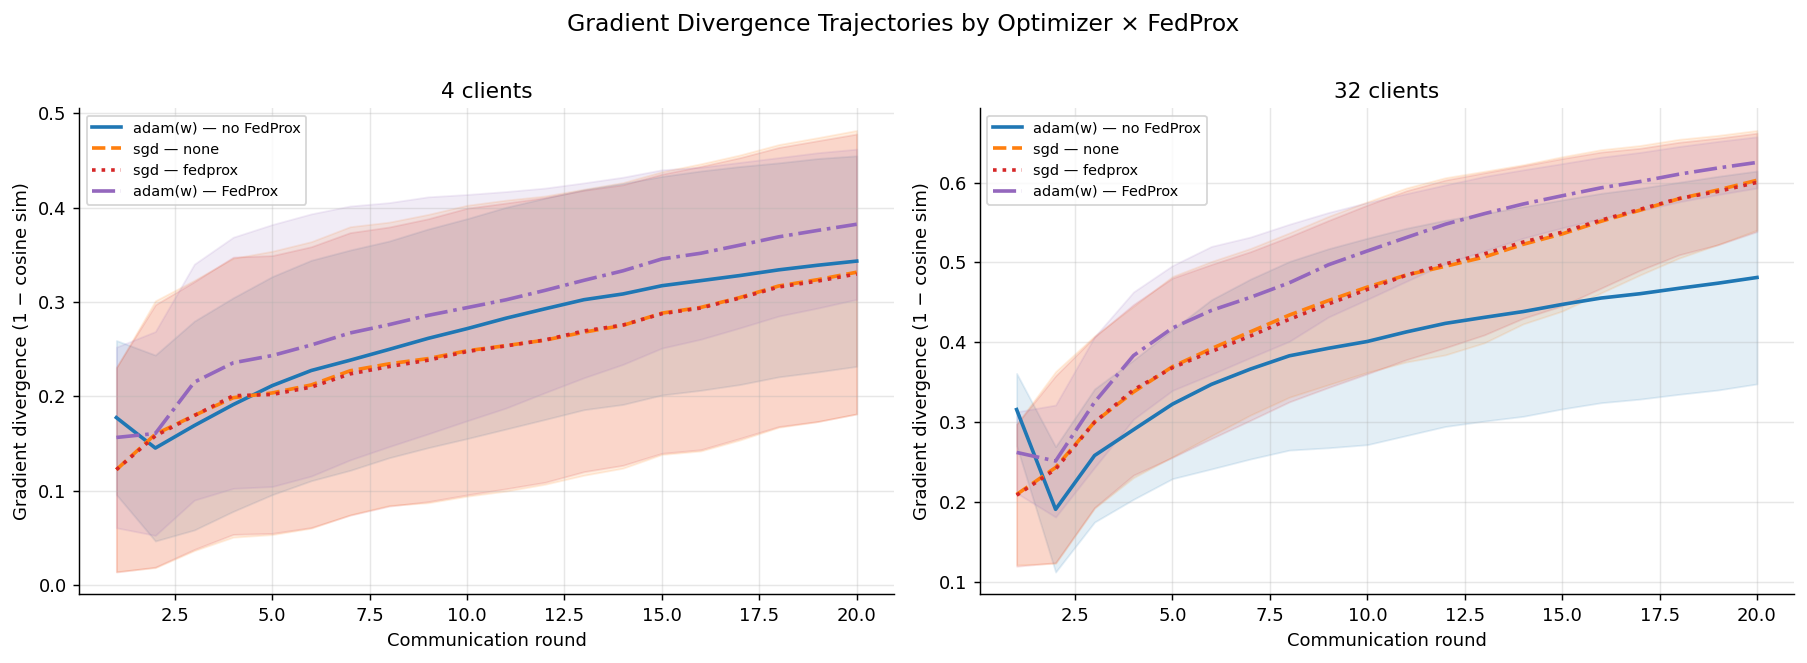

In [8]:
# Reconstruct per-round gradient divergence for every experiment,
# then average within each div_group.
DIV_GROUPS = [
    "adam(w) — no FedProx",
    "sgd — none",
    "sgd — fedprox",
    "adam(w) — FedProx",
]
GROUP_COLORS = {
    "adam(w) — no FedProx": "#1f77b4",
    "sgd — none":           "#ff7f0e",
    "sgd — fedprox":        "#d62728",
    "adam(w) — FedProx":    "#9467bd",
}
GROUP_LS = {
    "adam(w) — no FedProx": "-",
    "sgd — none":           "--",
    "sgd — fedprox":        ":",
    "adam(w) — FedProx":    "-.",
}

# Collect curves per group
from collections import defaultdict
group_curves = defaultdict(list)
for r in records:
    gd  = r["history"].get("grad_divergence", [])
    cfg = r.get("config", {})
    exp_id = r["exp_id"]
    if not gd:
        continue
    grp = df.loc[df["exp_id"] == exp_id, "div_group"].values
    if len(grp):
        group_curves[grp[0]].append(gd)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, nc in zip(axes, [4, 32]):
    sub_ids = set(df[df["num_clients"] == nc]["exp_id"])
    g_curves = defaultdict(list)
    for r in records:
        if r["exp_id"] not in sub_ids:
            continue
        gd = r["history"].get("grad_divergence", [])
        if not gd: continue
        grp = df.loc[df["exp_id"] == r["exp_id"], "div_group"].values
        if len(grp): g_curves[grp[0]].append(gd)

    for grp_name in DIV_GROUPS:
        curves = g_curves.get(grp_name, [])
        if not curves: continue
        max_len = max(len(c) for c in curves)
        padded  = [c + [c[-1]]*(max_len - len(c)) for c in curves]
        arr     = np.array(padded)
        mean_c  = arr.mean(0)
        std_c   = arr.std(0)
        x = np.arange(1, max_len + 1)
        color = GROUP_COLORS[grp_name]
        ls    = GROUP_LS[grp_name]
        ax.plot(x, mean_c, label=grp_name, color=color, lw=2, ls=ls)
        ax.fill_between(x, mean_c - std_c, mean_c + std_c, color=color, alpha=0.12)

    ax.set_title(f"{nc} clients")
    ax.set_xlabel("Communication round")
    ax.set_ylabel("Gradient divergence (1 − cosine sim)")
    ax.legend(fontsize=8)

fig.suptitle("Gradient Divergence Trajectories by Optimizer × FedProx", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / "02_grad_divergence_plateaus.png", bbox_inches="tight")
plt.show()

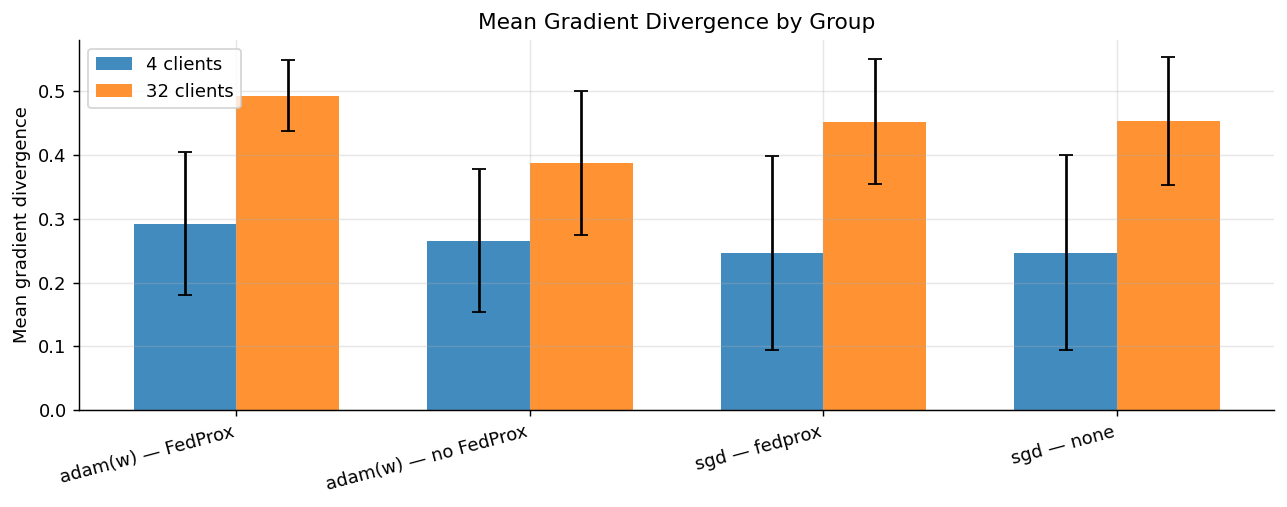

In [9]:
# Bar chart: mean gradient divergence by group and num_clients
pivot_gd = df.pivot_table(
    values="mean_grad_div", index="div_group",
    columns="num_clients", aggfunc=["mean","std"]
)

fig, ax = plt.subplots(figsize=(10, 4))
x       = np.arange(len(pivot_gd))
width   = 0.35
for i, nc in enumerate([4, 32]):
    means = pivot_gd["mean"][nc].values
    stds  = pivot_gd["std"][nc].values
    ax.bar(x + (i - 0.5)*width, means, width, yerr=stds,
           label=f"{nc} clients", capsize=4, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pivot_gd.index, rotation=15, ha="right")
ax.set_ylabel("Mean gradient divergence")
ax.set_title("Mean Gradient Divergence by Group")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "02b_grad_divergence_bar.png", bbox_inches="tight")
plt.show()

## 6. Effect of FedProx regularization per optimizer

For each optimizer, compare final global val loss with and without FedProx.

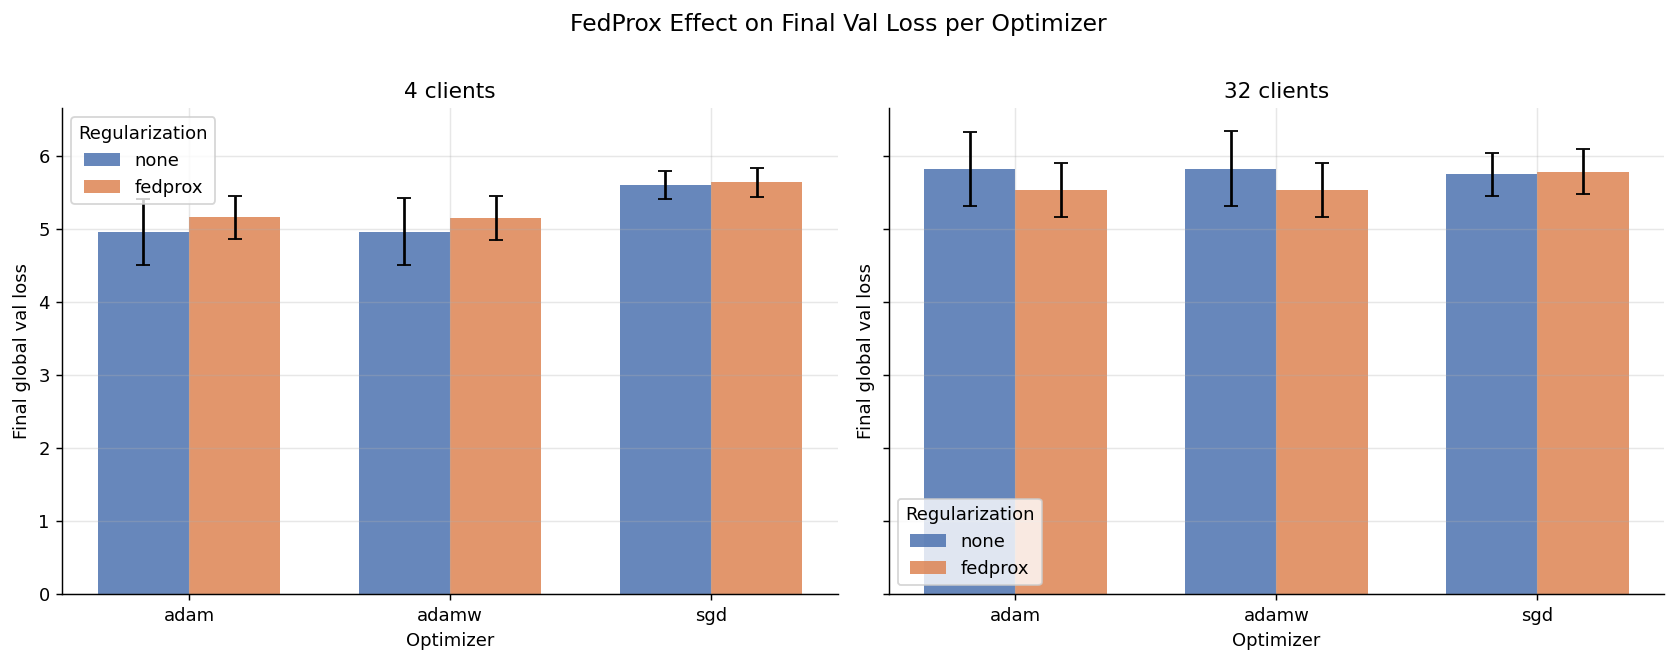

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, nc in zip(axes, [4, 32]):
    sub  = df[df["num_clients"] == nc]
    grp  = sub.groupby(["optimizer","regularization"])["final_global_val"].agg(["mean","std"])
    opts = sorted(df["optimizer"].unique())

    x       = np.arange(len(opts))
    width   = 0.35
    for i, reg in enumerate(["none", "fedprox"]):
        means, stds = [], []
        for opt in opts:
            try:
                means.append(grp.loc[(opt, reg), "mean"])
                stds.append(grp.loc[(opt, reg), "std"])
            except KeyError:
                means.append(np.nan); stds.append(0)
        ax.bar(x + (i - 0.5)*width, means, width, yerr=stds,
               label=reg, capsize=4, alpha=0.85,
               color=("#4C72B0" if reg == "none" else "#DD8452"))

    ax.set_xticks(x); ax.set_xticklabels(opts)
    ax.set_title(f"{nc} clients")
    ax.set_xlabel("Optimizer")
    ax.set_ylabel("Final global val loss")
    ax.legend(title="Regularization")

fig.suptitle("FedProx Effect on Final Val Loss per Optimizer", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / "03_fedprox_effect.png", bbox_inches="tight")
plt.show()

In [11]:
# Delta table: how much does FedProx help (negative = improvement)
grp = df.groupby(["num_clients","optimizer","regularization"])["final_global_val"].mean().unstack("regularization")
grp["fedprox_delta"] = grp["fedprox"] - grp["none"]
grp["fedprox_delta_pct"] = (grp["fedprox_delta"] / grp["none"] * 100).round(2)
grp.round(4)

regularization         fedprox    none  fedprox_delta  fedprox_delta_pct
num_clients optimizer                                                   
4           adam        5.1645  4.9605         0.2041               4.11
            adamw       5.1561  4.9711         0.1850               3.72
            sgd         5.6442  5.6080         0.0362               0.64
32          adam        5.5396  5.8280        -0.2884              -4.95
            adamw       5.5376  5.8313        -0.2937              -5.04
            sgd         5.7898  5.7575         0.0322               0.56

## 7. FedAvg vs FedAdam

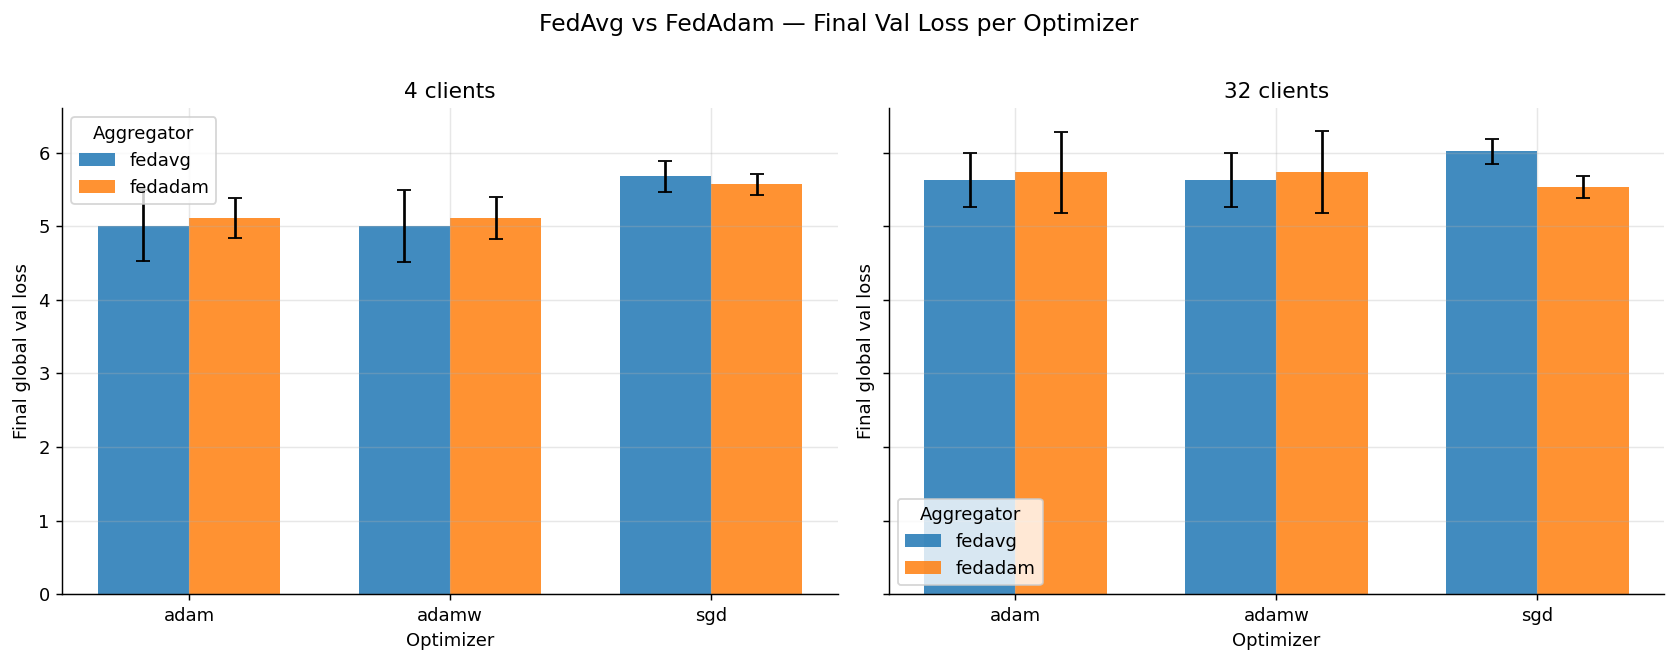

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, nc in zip(axes, [4, 32]):
    sub = df[df["num_clients"] == nc]
    grp = sub.groupby(["aggregator","optimizer"])["final_global_val"].agg(["mean","std"])
    opts = sorted(df["optimizer"].unique())

    x = np.arange(len(opts))
    width = 0.35
    for i, agg in enumerate(["fedavg", "fedadam"]):
        means, stds = [], []
        for opt in opts:
            try:
                means.append(grp.loc[(agg, opt), "mean"])
                stds.append(grp.loc[(agg, opt), "std"])
            except KeyError:
                means.append(np.nan); stds.append(0)
        ax.bar(x + (i-0.5)*width, means, width, yerr=stds,
               label=agg, capsize=4, alpha=0.85)

    ax.set_xticks(x); ax.set_xticklabels(opts)
    ax.set_title(f"{nc} clients")
    ax.set_xlabel("Optimizer")
    ax.set_ylabel("Final global val loss")
    ax.legend(title="Aggregator")

fig.suptitle("FedAvg vs FedAdam — Final Val Loss per Optimizer", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / "04_aggregator_comparison.png", bbox_inches="tight")
plt.show()

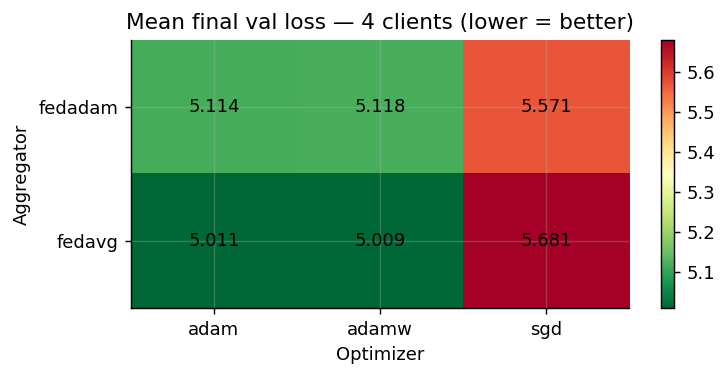

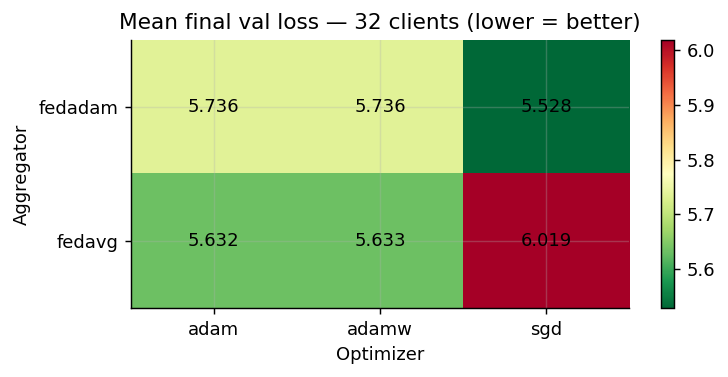

In [13]:
# Heatmap: mean final val loss — aggregator × optimizer (averaged over all other axes)
import matplotlib.colors as mcolors

for nc in [4, 32]:
    sub   = df[df["num_clients"] == nc]
    pivot = sub.pivot_table(values="final_global_val",
                            index="aggregator", columns="optimizer", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(6, 3))
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Optimizer"); ax.set_ylabel("Aggregator")
    ax.set_title(f"Mean final val loss — {nc} clients (lower = better)")
    plt.colorbar(im, ax=ax)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f"04b_heatmap_agg_opt_c{nc}.png", bbox_inches="tight")
    plt.show()

## 8. Global val loss learning curves

Average global val loss trajectory, grouped by various axes.

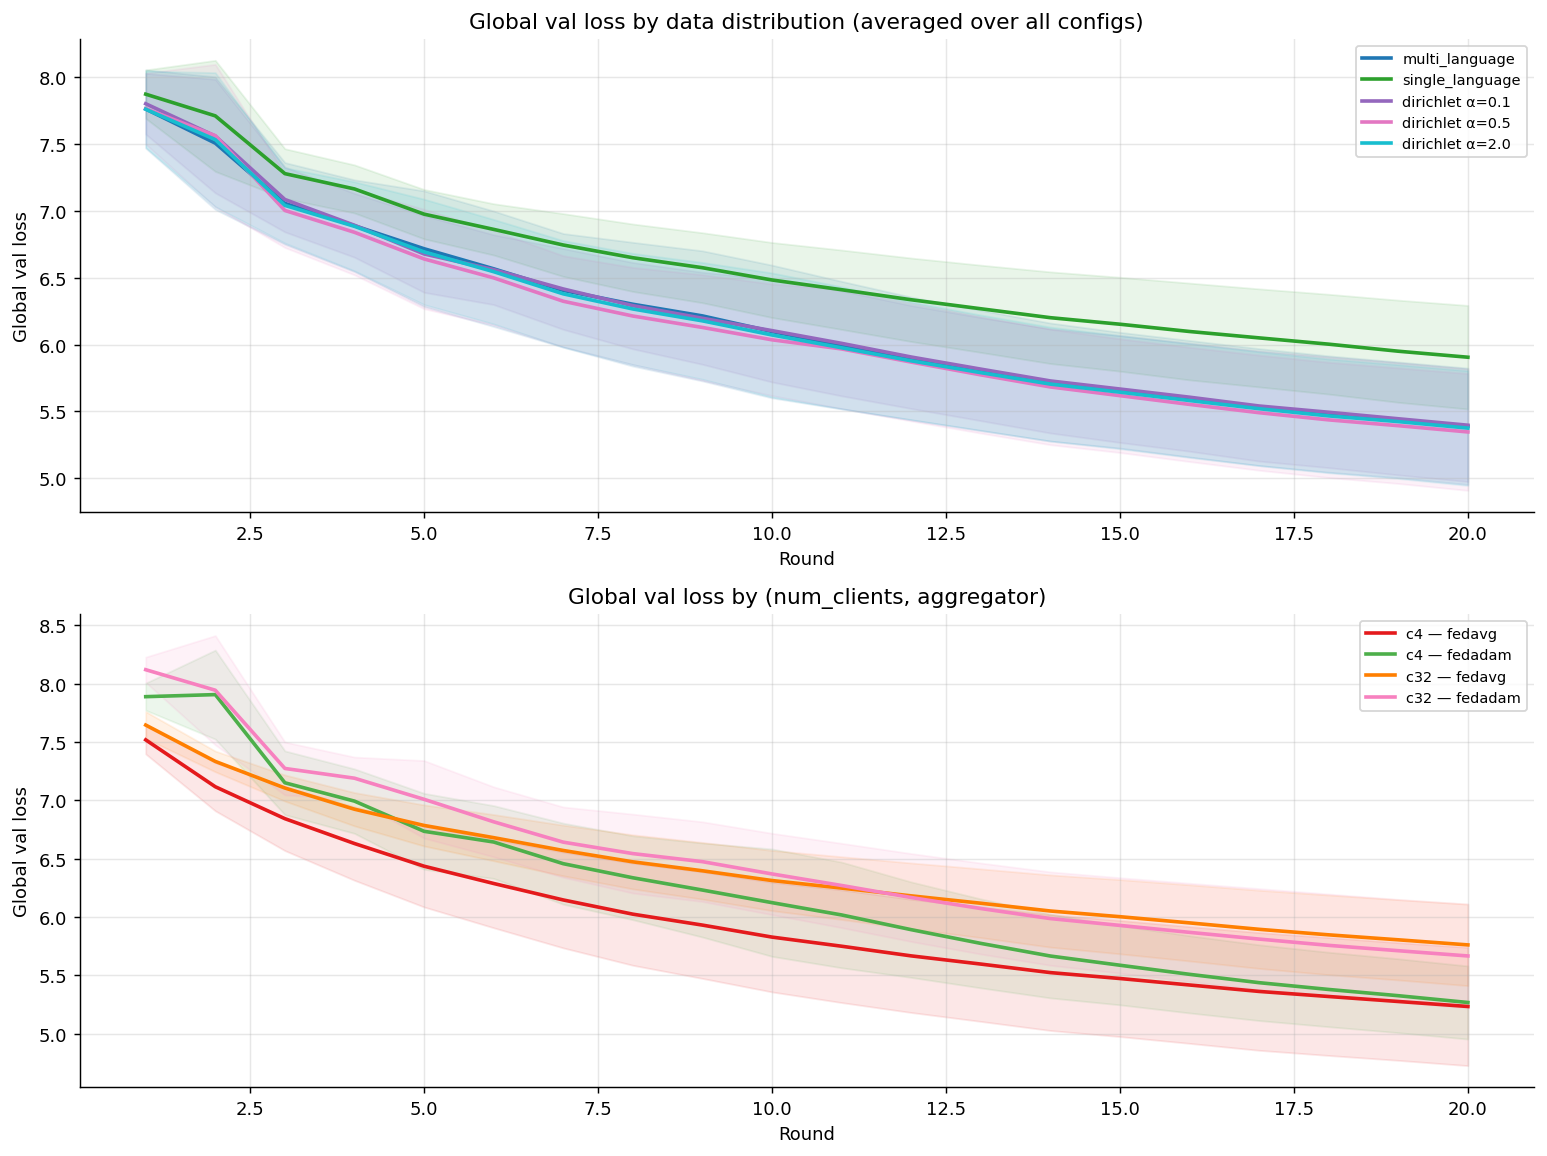

In [14]:
def avg_curves(sub_records, key="global_val_loss"):
    """Return (x, mean, std) averaged over a list of history dicts."""
    curves = [r["history"].get(key, []) for r in sub_records if r["history"].get(key)]
    if not curves: return None, None, None
    max_len = max(len(c) for c in curves)
    padded  = [c + [c[-1]]*(max_len - len(c)) for c in curves]
    arr     = np.array(padded)
    return np.arange(1, max_len+1), arr.mean(0), arr.std(0)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# ── Panel A: by distribution ──────────────────────────────────────────────
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 0.9, 5))
dist_order = ["multi_language", "single_language",
              "dirichlet α=0.1", "dirichlet α=0.5", "dirichlet α=2.0"]
for color, label in zip(colors, dist_order):
    ids = set(df[df["dist_label"] == label]["exp_id"])
    sub = [r for r in records if r["exp_id"] in ids]
    x, mean_c, std_c = avg_curves(sub)
    if x is None: continue
    ax.plot(x, mean_c, label=label, color=color, lw=2)
    ax.fill_between(x, mean_c - std_c, mean_c + std_c, color=color, alpha=0.1)
ax.set_title("Global val loss by data distribution (averaged over all configs)")
ax.set_xlabel("Round"); ax.set_ylabel("Global val loss"); ax.legend(fontsize=8)

# ── Panel B: by (num_clients, aggregator) ────────────────────────────────
ax = axes[1]
palette = plt.cm.Set1(np.linspace(0, 0.8, 4))
for color, (nc, agg) in zip(palette, [(4,"fedavg"),(4,"fedadam"),(32,"fedavg"),(32,"fedadam")]):
    ids = set(df[(df["num_clients"]==nc) & (df["aggregator"]==agg)]["exp_id"])
    sub = [r for r in records if r["exp_id"] in ids]
    x, mean_c, std_c = avg_curves(sub)
    if x is None: continue
    ax.plot(x, mean_c, label=f"c{nc} — {agg}", color=color, lw=2)
    ax.fill_between(x, mean_c - std_c, mean_c + std_c, color=color, alpha=0.1)
ax.set_title("Global val loss by (num_clients, aggregator)")
ax.set_xlabel("Round"); ax.set_ylabel("Global val loss"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / "05_learning_curves.png", bbox_inches="tight")
plt.show()

## 9. Dirichlet heterogeneity (α sweep)

Lower α = more skewed distribution across clients.

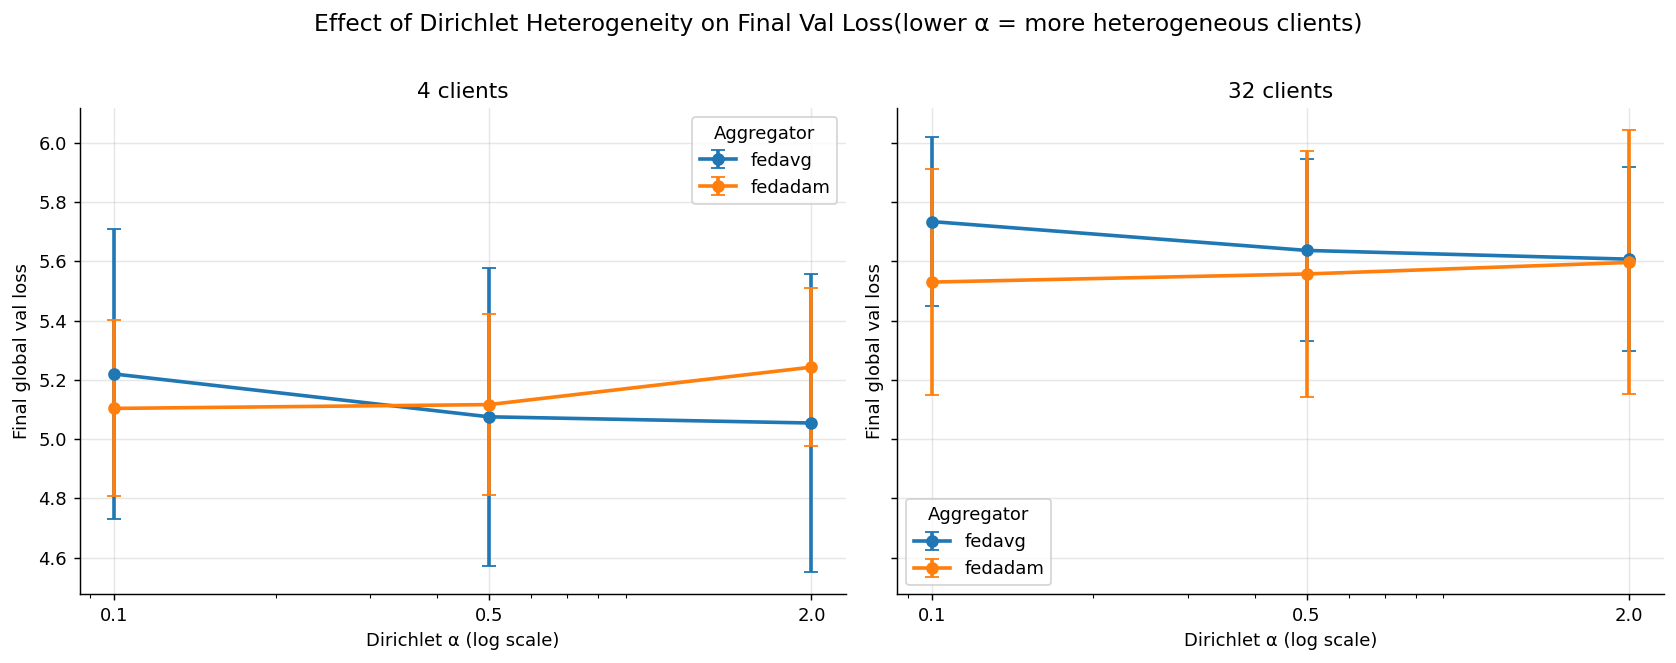

In [16]:
sub_dir = df[df["distribution"] == "dirichlet"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, nc in zip(axes, [4, 32]):
    sub = sub_dir[sub_dir["num_clients"] == nc]
    grp = sub.groupby(["dirichlet_alpha","aggregator"])["final_global_val"].agg(["mean","std"])
    alphas = sorted(sub["dirichlet_alpha"].unique())

    for agg, color in zip(["fedavg","fedadam"], ["#1f77b4","#ff7f0e"]):
        means = [grp.loc[(a, agg), "mean"] if (a,agg) in grp.index else np.nan for a in alphas]
        stds  = [grp.loc[(a, agg), "std"]  if (a,agg) in grp.index else 0      for a in alphas]
        ax.errorbar(alphas, means, yerr=stds, marker="o", lw=2,
                    label=agg, color=color, capsize=4)

    ax.set_xscale("log")
    ax.set_xticks(alphas); ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.set_title(f"{nc} clients")
    ax.set_xlabel("Dirichlet α (log scale)"); ax.set_ylabel("Final global val loss")
    ax.legend(title="Aggregator")

fig.suptitle("Effect of Dirichlet Heterogeneity on Final Val Loss"\
             "(lower α = more heterogeneous clients)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / "06_dirichlet_alpha.png", bbox_inches="tight")
plt.show()

## 10. FL vs centralized baseline

Points **below the diagonal** mean FL matches or beats the centralized model.

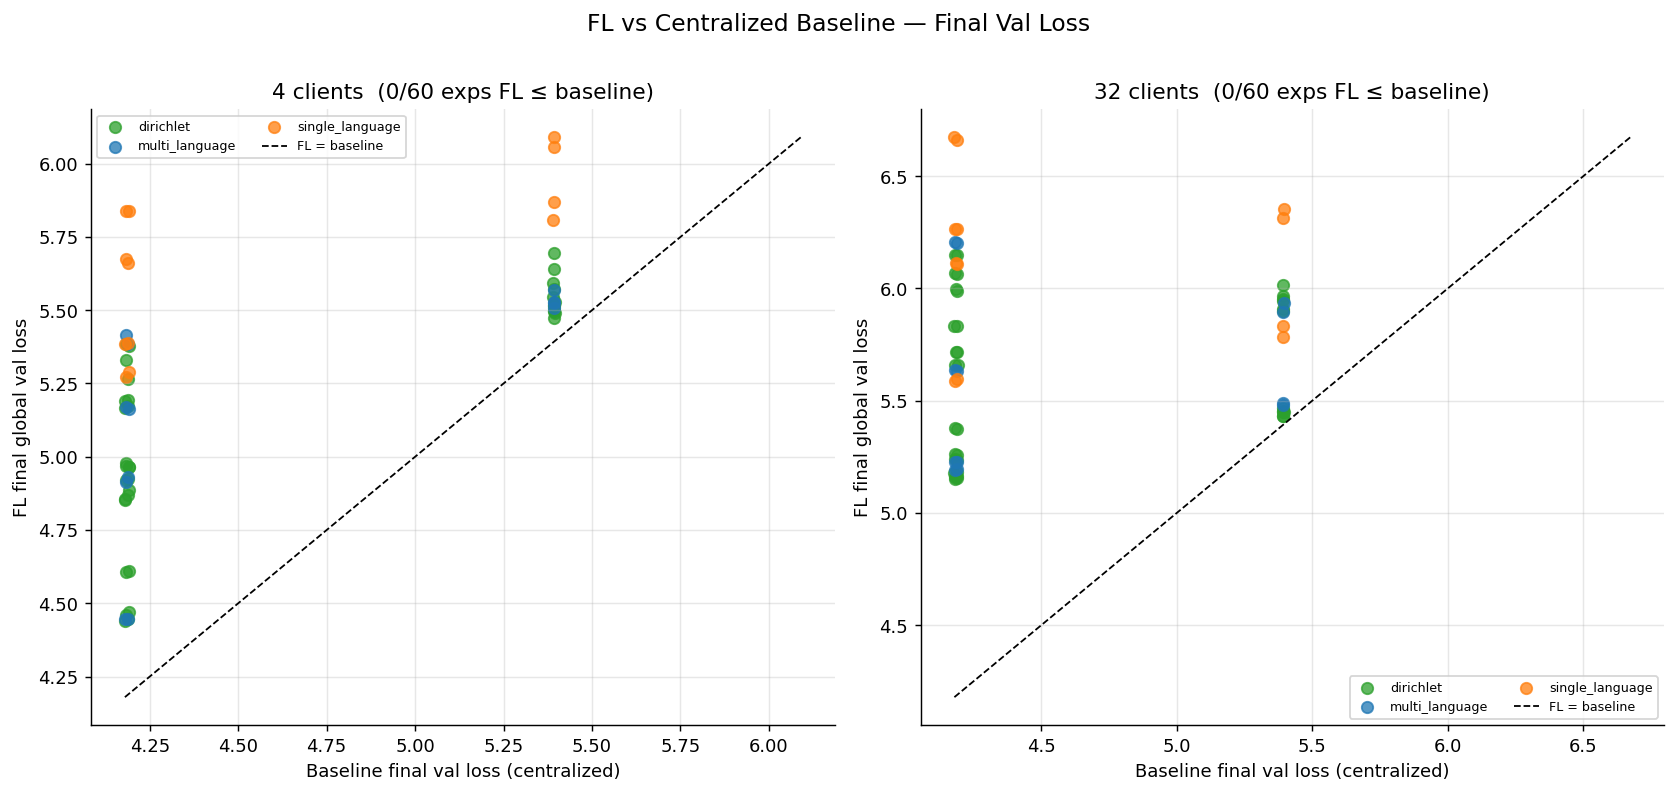


FL better than baseline:
num_clients
4     0
32    0
Name: n_better, dtype: int64


In [17]:
sub = df.dropna(subset=["baseline_final_val","final_global_val"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, nc in zip(axes, [4, 32]):
    s = sub[sub["num_clients"] == nc]
    colors_map = {"multi_language":"#1f77b4","single_language":"#ff7f0e",
                  "dirichlet":"#2ca02c"}
    for dist in s["distribution"].unique():
        sd = s[s["distribution"] == dist]
        ax.scatter(sd["baseline_final_val"], sd["final_global_val"],
                   label=dist, alpha=0.75, s=40,
                   color=colors_map.get(dist, "gray"))

    lo = min(s[["baseline_final_val","final_global_val"]].min())
    hi = max(s[["baseline_final_val","final_global_val"]].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="FL = baseline")
    ax.set_xlabel("Baseline final val loss (centralized)")
    ax.set_ylabel("FL final global val loss")
    ax.set_title(f"{nc} clients")
    ax.legend(fontsize=7, ncol=2)

    better = (s["fl_minus_baseline"] < 0).sum()
    ax.set_title(f"{nc} clients  ({better}/{len(s)} exps FL ≤ baseline)")

fig.suptitle("FL vs Centralized Baseline — Final Val Loss", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / "07_fl_vs_baseline.png", bbox_inches="tight")
plt.show()

print("\nFL better than baseline:")
print(df.groupby("num_clients").apply(lambda x: (x["fl_minus_baseline"]<0).sum()).rename("n_better"))

## 11. Best configurations

In [18]:
# Full ranking table
ranking_cols = ["exp_id","num_clients","distribution","aggregator",
                "regularization","optimizer","final_global_val","baseline_final_val"]
df.sort_values("final_global_val")[ranking_cols].reset_index(drop=True).head(20)\
  .style.background_gradient(subset=["final_global_val"], cmap="RdYlGn_r")

,exp_id,num_clients,distribution,aggregator,regularization,optimizer,final_global_val,baseline_final_val
0,c4_dirichlet2.0_fedavg_none_adamw,4,dirichlet,fedavg,none,adamw,4.441119,4.180112
1,c4_dirichlet2.0_fedavg_none_adam,4,dirichlet,fedavg,none,adam,4.446316,4.188895
2,c4_multi_language_fedavg_none_adamw,4,multi_language,fedavg,none,adamw,4.446611,4.181414
3,c4_multi_language_fedavg_none_adam,4,multi_language,fedavg,none,adam,4.446938,4.189163
4,c4_dirichlet0.5_fedavg_none_adamw,4,dirichlet,fedavg,none,adamw,4.460881,4.183453
5,c4_dirichlet0.5_fedavg_none_adam,4,dirichlet,fedavg,none,adam,4.469333,4.190019
6,c4_dirichlet0.1_fedavg_none_adamw,4,dirichlet,fedavg,none,adamw,4.606828,4.184026
7,c4_dirichlet0.1_fedavg_none_adam,4,dirichlet,fedavg,none,adam,4.611700,4.189923
8,c4_dirichlet0.1_fedadam_fedprox_adamw,4,dirichlet,fedadam,fedprox,adamw,4.852621,4.181029
9,c4_dirichlet0.5_fedadam_fedprox_adamw,4,dirichlet,fedadam,fedprox,adamw,4.855243,4.179744


In [19]:
# Summary pivot: best aggregator/optimizer combo per num_clients
for nc in [4, 32]:
    print(f"\n── {nc} clients ──")
    sub   = df[df["num_clients"] == nc]
    pivot = sub.pivot_table(
        values="final_global_val",
        index=["aggregator","regularization"],
        columns="optimizer",
        aggfunc="mean"
    ).round(4)
    print(pivot.to_string())


── 4 clients ──
optimizer                    adam   adamw     sgd
aggregator regularization                        
fedadam    fedprox         4.9802  4.9627  5.5848
           none            5.2483  5.2741  5.5571
fedavg     fedprox         5.3489  5.3495  5.7036
           none            4.6726  4.6681  5.6589

── 32 clients ──
optimizer                    adam   adamw     sgd
aggregator regularization                        
fedadam    fedprox         5.2581  5.2529  5.5382
           none            6.2135  6.2190  5.5179
fedavg     fedprox         5.8210  5.8223  6.0413
           none            5.4425  5.4436  5.9972


In [20]:
# Save the full DataFrame for further analysis
df.to_csv("results_summary.csv", index=False)
print("Saved → results_summary.csv")

Saved → results_summary.csv
